In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
h_true = np.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=np.float64)
M = len(h_true)

# ==============================================================
# AR(1) generator with target eigenvalue spread
# ==============================================================
def ar1Input(a, N, sigma_v2=1.0):
  v = np.sqrt(sigma_v2) * np.random.randn(N)
  x = np.zeros(N)
  for n in range(1, N):
    x[n] = a * x[n-1] + v[n]
  x /= np.std(x)
  return x


def runSysID(
    model,
    spread=20,
    N=500,
    sigma_n2=1e-4,
    n_runs=200,
    burnin=2000,
):
  """
  Monte-Carlo averaged MSE learning curve
  """
  a = adspfilter.ar1poleSpreadSearch(spread, M)

  # determine output length dynamically
  x_test = ar1Input(a, N + M)
  d_test = np.convolve(x_test, h_true)[:N]
  model.w = np.zeros(M)
  _, e_test, _ = model(x_test[:N], d_test, train=False)
  out_len = len(e_test)

  mse_runs = np.zeros((n_runs, out_len))

  for r in range(n_runs):
    x = ar1Input(a, N + M)        
    noise = np.sqrt(sigma_n2) * np.random.randn(N)
    d = np.convolve(x, h_true)[:N] + noise
    model.w = np.zeros(M)                      # reset weights
    y, e, _ = model(x[:N], d, train=True)
    mse_runs[r] = np.abs(e)**2

  mse_avg = np.mean(mse_runs, axis=0)
  burn = min(burnin, out_len // 2)
  misadj = (np.mean(mse_avg[burn:]) - sigma_n2) / sigma_n2

  return mse_avg, misadj

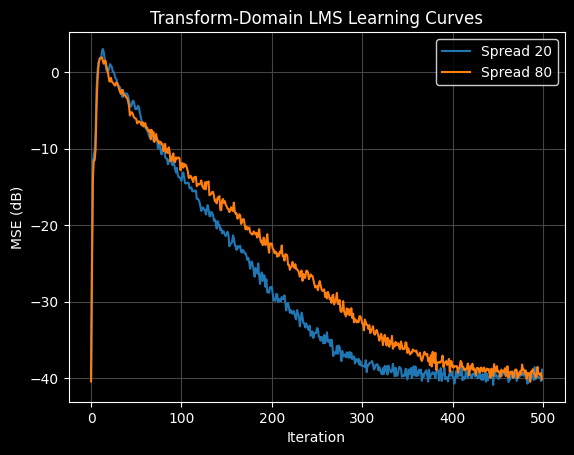

Misadjustment Spread 20: 0.4256575957132238
Misadjustment Spread 80: 2.556811746388732


In [3]:
# Example 4.8 — Transform-Domain LMS
# Transform-Domain LMS (DCT)
td_model = adspfilter.TransformDomain(
    mu=0.01,
    filter_order=M-1,
    matrix="dct",
    alpha=0.05,
    gamma=1e-6
)

mse20, M20 = runSysID(td_model, spread=20)
mse80, M80 = runSysID(td_model, spread=80)

plt.figure()
plt.plot(10*np.log10(mse20), label="Spread 20")
plt.plot(10*np.log10(mse80), label="Spread 80")
plt.title("Transform-Domain LMS Learning Curves")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()

print("Misadjustment Spread 20:", M20)
print("Misadjustment Spread 80:", M80)

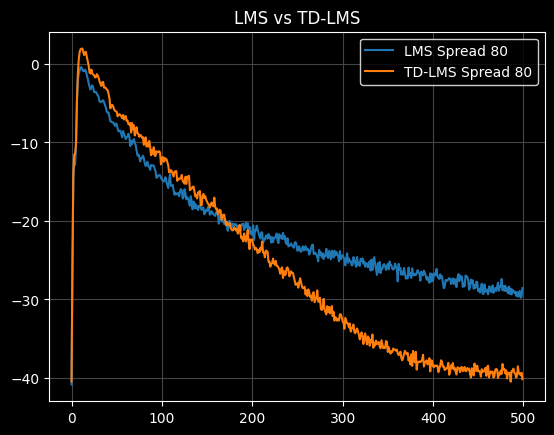

In [4]:
lms_model = adspfilter.LMS(mu=0.01, filter_order=M-1)

mse_lms_80, M_lms_80 = runSysID(lms_model, spread=80)

plt.figure()
plt.plot(10*np.log10(mse_lms_80), label="LMS Spread 80")
plt.plot(10*np.log10(mse80), label="TD-LMS Spread 80")
plt.legend()
plt.title("LMS vs TD-LMS")
plt.grid()
plt.show()

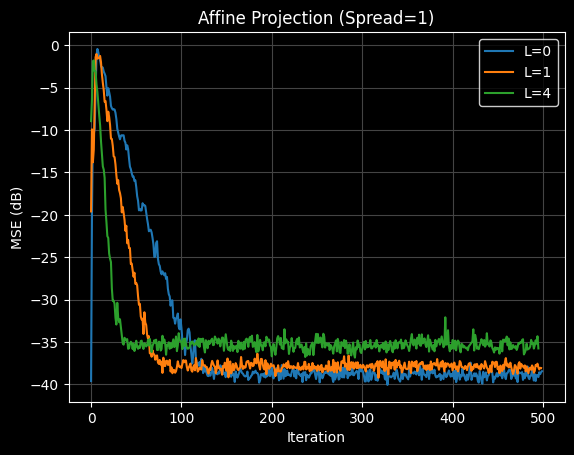

In [5]:
for L in [0, 1, 4]:
  apa = adspfilter.AffineProjection(mu=0.4, filter_order=M-1, P=L)
  mse, M_val = runSysID(apa, spread=1)

  plt.plot(10*np.log10(mse), label=f"L={L}")

plt.title("Affine Projection (Spread=1)")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.legend()
plt.grid()
plt.show()

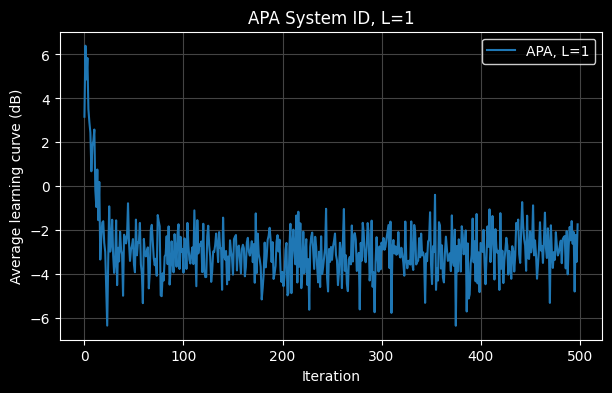

In [6]:
def apaSysID4QamProb3132(
    n_iter=500,
    mu=0.1,
    L=1,
    sigma_n2=0.04,
    delta=1e-3,
    seed=None,
):
    rng = np.random.default_rng(seed)

    w0 = np.array([
        0.32 + 0.21j,
       -0.30 + 0.70j,
        0.50 - 0.80j,
        0.20 + 0.50j
    ], dtype=np.complex128)

    n_taps = len(w0)

    x = (
        rng.choice([-1, 1], size=n_iter)
        + 1j * rng.choice([-1, 1], size=n_iter)
    ).astype(np.complex128) / np.sqrt(2.0)

    noise = np.sqrt(sigma_n2 / 2.0) * (
        rng.standard_normal(n_iter) + 1j * rng.standard_normal(n_iter)
    )

    x_pad = np.concatenate([np.zeros(n_taps - 1, dtype=np.complex128), x])

    d = np.zeros(n_iter, dtype=np.complex128)
    for k in range(n_iter):
        xk = x_pad[k:k + n_taps]   # same ordering as class
        d[k] = np.vdot(w0, xk) + noise[k]

    apa = adspfilter.AffineProjection(
        filter_order=n_taps - 1,
        mu=mu,
        P=L,
        delta=delta,
        init_coef=np.ones(n_taps, dtype=np.complex64),
    )

    y, e, w_hist = apa(x, d, train=True)
    mse = np.abs(e) ** 2
    w_err = np.linalg.norm(w_hist - w0[None, :], axis=1)

    return y, e, w_hist, w_err, mse, w0


def runAPASysID4QamProb3132(
    n_exp=100,
    n_iter=500,
    mu=0.1,
    L=1,
    sigma_n2=0.04,
    delta=1e-3,
):
    mse_curves = []
    err_curves = []

    for exp_idx in range(n_exp):
        y, e, w_hist, w_err, mse, w0 = apaSysID4QamProb3132(
            n_iter=n_iter,
            mu=mu,
            L=L,
            sigma_n2=sigma_n2,
            delta=delta,
            seed=exp_idx,
        )
        mse_curves.append(mse)
        err_curves.append(np.abs(e))

    mse_curves = np.asarray(mse_curves)
    err_curves = np.asarray(err_curves)

    mse_avg = mse_curves.mean(axis=0)
    mse_avg_db = 10.0 * np.log10(np.maximum(mse_avg, 1e-12))
    err_avg = err_curves.mean(axis=0)

    return {
        "mse_curves": mse_curves,
        "err_curves": err_curves,
        "mse_avg": mse_avg,
        "mse_avg_db": mse_avg_db,
        "err_avg": err_avg,
        "w0": w0,
    }

res_L1 = runAPASysID4QamProb3132(
    n_exp=20,
    n_iter=500,
    mu=0.2,
    L=1,
    sigma_n2=0.4,
    delta=1e-12,
)

plt.figure(figsize=(7, 4))
plt.plot(res_L1["mse_avg_db"], label="APA, L=1")
plt.xlabel("Iteration")
plt.ylabel("Average learning curve (dB)")
plt.title("APA System ID, L=1")
plt.grid(True)
plt.legend()
plt.show()